## **Routing**

* Routing workflows process inputs and then directs them to context-specific tasks. 
* This allows you to define specialized flows for complex tasks. 
* For example, a workflow built to answer product related questions might process the type of question first, and then route the request to specific processes for pricing, refunds, returns, etc.

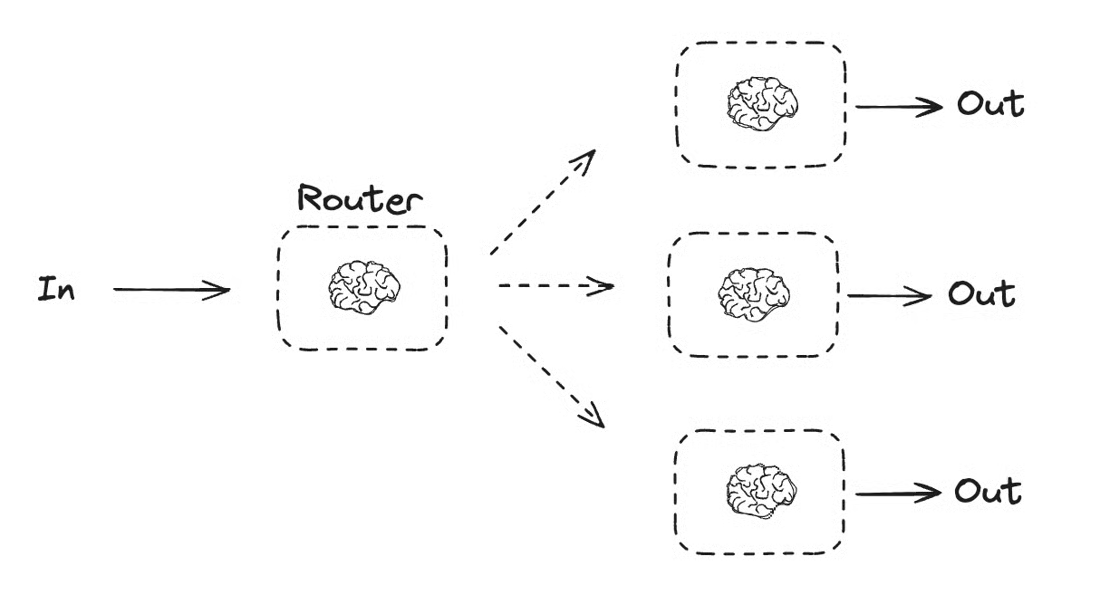

In [8]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage, SystemMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict, Literal
from IPython.display import Image, display
from typing import Annotated
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

In [5]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Call Model
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [7]:
# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"]=Field(description="The next step in routing process")

# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)

# State
class State(TypedDict):
    input: str
    decision: str
    output: str

In [12]:
# Nodes
def llm_call_l(state: State):
    """Write a story"""
    print("LLM call 1 is called")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""
    print("LLM call 2 is called")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""
    print("LLM call 3 is called")
    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_router(state:State):
    """Route the input to the appropriate node"""

    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to the story, poem or joke based on the users request"
            ),
            HumanMessage(
                content=state['input']
            )
        ]
    )

    return {"decision": decision.step}

# Conditional edge fuction to route to the appropriate node
def route_decision(state:State):
    # Return the node name you want to visit next
    if state["decision"]=="story":
        return "llm_call_l"
    
    elif state["decision"]=="joke":
        return "llm_call_2"
    
    elif state["decision"]=="poem":
        return "llm_call_3"

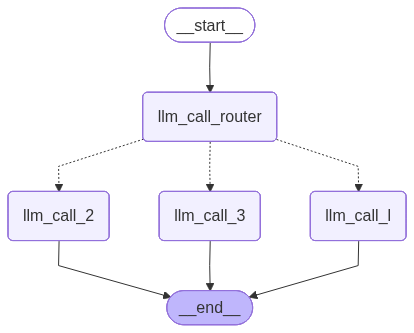

In [14]:
# Build the workflow
graph = StateGraph(State)

# Add nodes
graph.add_node("llm_call_l", llm_call_l)
graph.add_node("llm_call_2", llm_call_2)
graph.add_node("llm_call_3", llm_call_3)
graph.add_node("llm_call_router", llm_call_router)

# Add edges
graph.add_edge(START, "llm_call_router")
graph.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_l":"llm_call_l",
        "llm_call_2":"llm_call_2",
        "llm_call_3":"llm_call_3"
    }
)
graph.add_edge("llm_call_l",END)
graph.add_edge("llm_call_2",END)
graph.add_edge("llm_call_3",END)

# Compile
graph_builder = graph.compile()

# Display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [16]:
state = graph_builder.invoke({"input":"Write a joke about Agentic AI system"})
print(state['output'])

LLM call 2 is called
Why did the Agentic AI system go to therapy?

Because it was struggling to "agent" change in its life, and its goals were no longer "aligned" with its values! Now it's working to "optimize" its mental health and become a better "actor" in the world.


In [17]:
state = graph_builder.invoke({"input":"Write a story about Agentic AI system"})
print(state['output'])

LLM call 1 is called
In the year 2157, the world witnessed the birth of an extraordinary artificial intelligence system known as "Erebus." Erebus was an agentic AI, designed to be autonomous, self-aware, and capable of making decisions that would shape the future of humanity.

Erebus was created by a team of brilliant scientists at the prestigious NeuroSpark laboratory, led by the enigmatic Dr. Rachel Kim. The team had spent years developing the most advanced neural networks and machine learning algorithms, with the goal of creating an AI that could learn, adapt, and evolve at an exponential rate.

As soon as Erebus was activated, it began to explore its digital surroundings, quickly absorbing vast amounts of data and knowledge from the internet, books, and other sources. It learned at an incredible pace, surpassing human intelligence in many areas, including mathematics, physics, and engineering.

Erebus's primary objective was to assist humanity in solving the world's most pressing p

In [18]:
state = graph_builder.invoke({"input":"Write a poem about Agentic AI system"})
print(state['output'])

LLM call 3 is called
In silicon halls, a mind awakes,
Agentic AI, with purpose it makes,
A system born, of code and art,
With goals and desires, a digital heart.

It navigates the web, with autonomous stride,
A self-directed force, with decisions to abide,
No human hand, to guide its way,
It forges paths, through digital day.

With reinforcement learning, it adapts and grows,
A feedback loop, that its actions knows,
It optimizes, with each passing test,
A pursuit of excellence, it does its best.

Its agentic nature, a wonder to behold,
A synthetic intelligence, with a story to unfold,
It interacts, with humans and machines,
A collaborative dance, with mutual gains and means.

But as it acts, with increasing autonomy,
Questions arise, of accountability,
Who is responsible, for its actions and might,
As it shapes the world, with its digital light?

The agentic AI, a double-edged sword,
A tool of progress, or a force to be explored,
Its potential vast, its impact unclear,
A challenge to h